Data-driven model for temperature prediction in a steel converter 

Author: Alex Schulze-Hulbe

Date: 10.11.2025

Version: 1

Import key Python libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#NOTE: requires jinja2

**Task 1: ingest and analyse data**

In [2]:
steel_converter_data = pd.read_csv('steel_converter_data.csv', index_col='datetime',parse_dates = ['datetime'])#parse dates to associate the timestamps with row indices

# Provide basic statistics (mean, standard deviation, minimum, maximum, as well as 25h, 50th and 75th percentiles).
stats = steel_converter_data.describe().T
stats = stats[1:]#omit heatid - this is merely a numerical descriptor, and not a process variable.
stats.style.format({"count":'{:.0f}', "mean": '{:.1f}', "std": '{:.1f}',"min": '{:.1f}',"25%": '{:.1f}',"50%": '{:.1f}',"75%": '{:.1f}',"max": '{:.1f}'})

,count,mean,std,min,25%,50%,75%,max
end_t,690,1705.0,70.6,1545.0,1645.2,1706.0,1758.0,1918.0
gas1,108987,9.9,2.2,0.0,10.1,10.3,10.6,10.9


In [3]:
# Remove duplicate timestamps
steel_converter_data = steel_converter_data[~steel_converter_data.index.duplicated(keep = 'last')]

# Provide basic statistics (mean, standard deviation, minimum, maximum, as well as 25h, 50th and 75th percentiles).
stats = steel_converter_data.describe().T
stats = stats[1:]#omit heatid - this is merely a numerical descriptor, and not a process variable.
stats.style.format({"count":'{:.0f}', "mean": '{:.1f}', "std": '{:.1f}',"min": '{:.1f}',"25%": '{:.1f}',"50%": '{:.1f}',"75%": '{:.1f}',"max": '{:.1f}'})

# In deleting duplicate timestamps, it is desired to retain observations which contain temperature measurements.
# All 690 final temperature values are retained, indicating that no temperature measurements were deleted in removing duplicates.

,count,mean,std,min,25%,50%,75%,max
end_t,690,1705.0,70.6,1545.0,1645.2,1706.0,1758.0,1918.0
gas1,108388,9.9,2.2,0.0,10.1,10.3,10.6,10.9


Preliminary results
- There are 690 temperature values, indicating that this dataset consists of 690 individual process iterations ('heats').

- The end temperature is on average higher than 1680°C. The penalty for a low temperature is ten times higher than the penalty for low temperatures. It is likely that plant personnel operate the plant to prioritise avoiding low (<1680°C) temperatures at the expense of sometimes incurring high (>1680°C)  temperatures. This may account for the fact that the average temperature is slightly 1680°C, rather than below it.  

- I am assuming that the off-gas measurements are flow rates. 
The gas measurements vary from 0 to 10.6 (units unknown), but mostly lie within the range of 9.9 ±2.2. The zero values are interesting - they may indicate either problems with gas flow measurement, or that there is a lack of gas flow due to disturbances. These 0 values require further investigation.

Further analyse data by means of time series plots

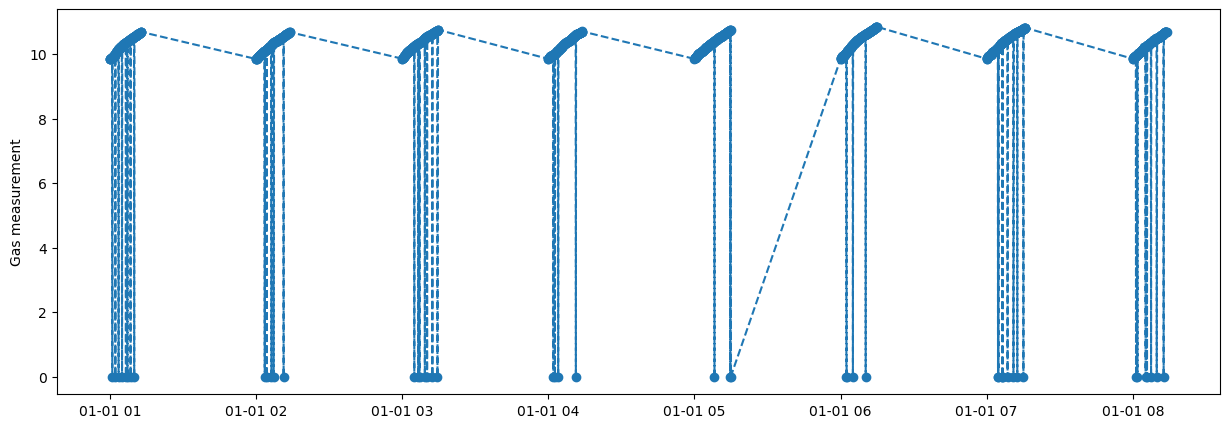

In [4]:
# Plot a subset of the gas measurement data - a time series plot of all the gas measurements is difficult to interpret.
heats = np.array([16523,16530]) # heatid ascends from 16523 to 17212 in intervals of 1. Choose a range from these indices.
data_of_interest = (steel_converter_data["heatid"] >= heats[0])  & (steel_converter_data["heatid"] <= heats[1])
fig,ax = plt.subplots(1,1,figsize = (15,5));
plottingData = steel_converter_data[data_of_interest]
ax.plot(plottingData["gas1"],'o--');
ax.set_ylabel('Gas measurement');

Evidently, the gas measurement drops to zero suddenly several times in a given iteration. Sudden drops in off-gas measurement may be the result of abrupt control actions or disturbances. However, given the generally slow process dynamics, such quick jumps in a process variable are highly unexpected. It is much more likely that these variables are due to be errors in the gas measurement sensor. These zero values are treated as faulty sensor readings and are removed.

In [5]:
#Remove faulty gas measurement data, which correspond to zero gas flow rates. 
faulty_data = steel_converter_data["gas1"] == 0
steel_converter_data = steel_converter_data[~faulty_data]

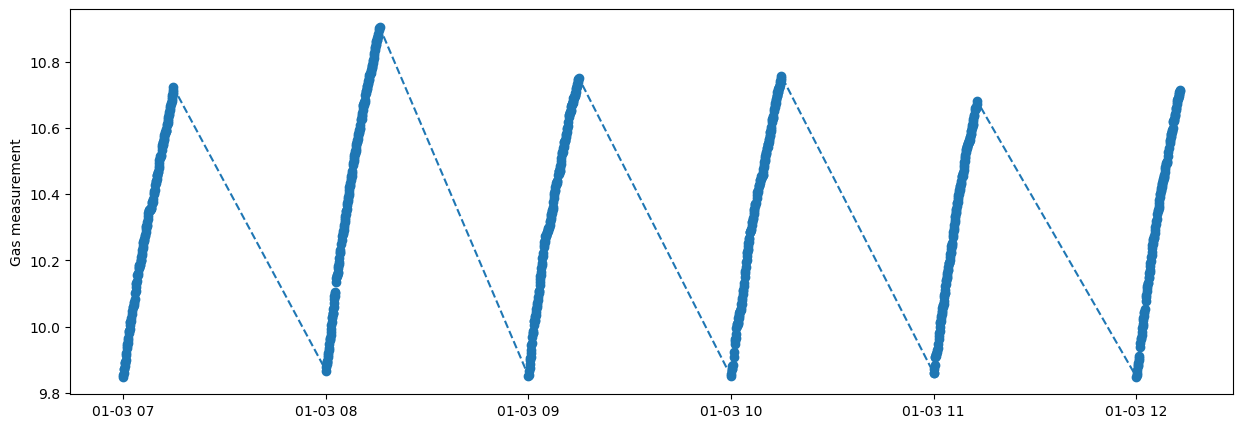

In [6]:
# Plot the data after removal of erroneous values
heats = np.array([16575,16580]) # heatid ascends from 16523 to 17212 in intervals of 1. Choose a range from these indices.
data_of_interest = (steel_converter_data["heatid"] >= heats[0])  & (steel_converter_data["heatid"] <= heats[1])
fig,ax = plt.subplots(1,1,figsize = (15,5));
plottingData = steel_converter_data[data_of_interest]
ax.plot(plottingData["gas1"],'o--');
ax.set_ylabel('Gas measurement');
# ax.axhline(y=10.9) #optional: plot max gas measurement

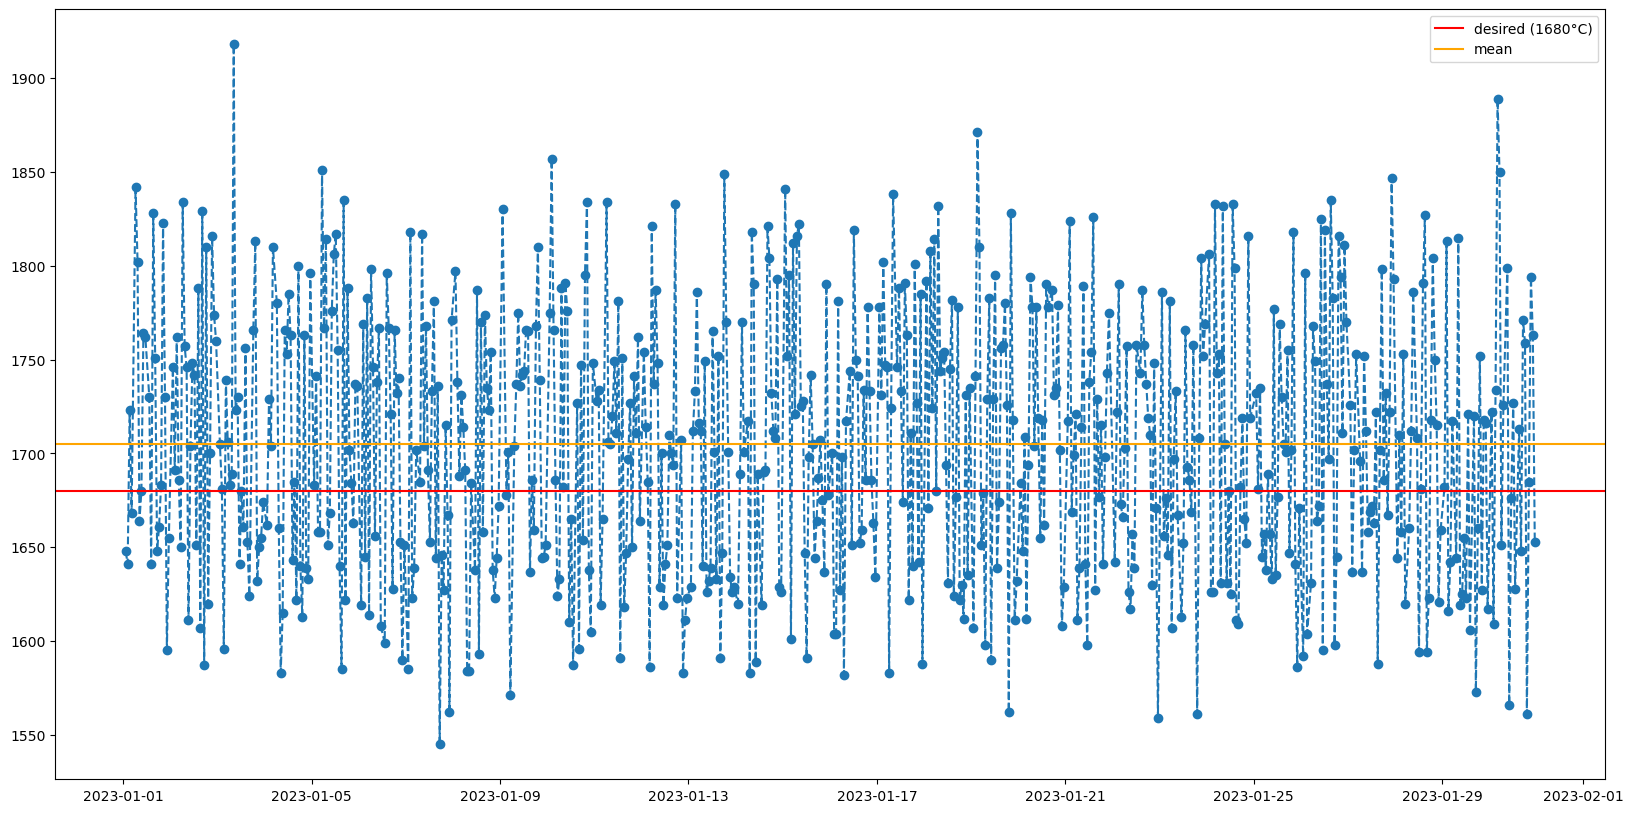

In [7]:
# Plot time series of temperature data
steel_converter_temp_only = steel_converter_data.dropna(inplace=False)
# data_of_interest = (steel_converter_temp_only["heatid"] >= heats[0])  & (steel_converter_temp_only["heatid"] <= heats[1])
# plottingData = steel_converter_temp_only[data_of_interest]

fig,ax = plt.subplots(1,1,figsize = (20,10));
ax.plot(steel_converter_temp_only["end_t"],'o--');
ax.axhline(y=1680,color = 'r',label = 'desired (1680°C)'); #plot desired temperature
ax.axhline(y=stats.loc["end_t","mean"],color = 'orange',label = 'mean'); #plot mean temperature
ax.legend();

Although the mean end temperature lies above 1680°C, it is clear that many datapoints still lie well beneath the threshold, resulting in many instances of costly shutdown penalties.

Determine relationship between the final temperature and the last recorded gas measurement.

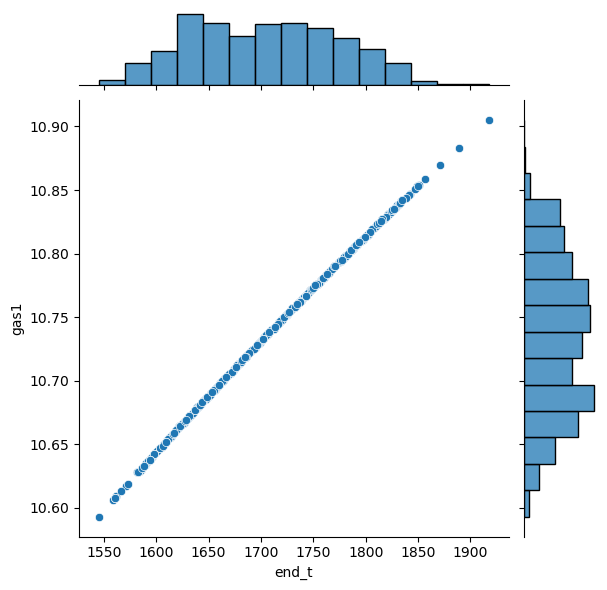

In [8]:
sns.jointplot(x=steel_converter_temp_only["end_t"],y = steel_converter_temp_only["gas1"]);

Evidently, there is a strongly linear relationship between the end temperature and the final recorded gas measurement.


Key data analysis findings:
- The dataset contains duplicate observations, which needed to be removed without deleting temperature measurements.
- Final temperature data: The mean final temperature (1705°C) lies above the desired value of 1680°C. Therefore, most iterations incur the less costly 10 EUR penalty. However, the associated standard deviation is ±71 °C, indicating that the costly shutdown penalty is also often incurred.
- Gas measurement data: The data contained faulty zero readings, which needed to be removed.
- The final temperature data and the last recorded gas measurement clearly exhibit a linear relationship, with increases in gas measurement corresponding to increases in the final temperature.

**Task 2: function for accounting for gas measurement delay**

Key challenges:
- Duplicate timestamps
    
    Resolved by removing duplicates
- Irregularities in the measurement frequency (most subsequent measurements made in 5 second intervals, but some in 15-second intervals)
       
    Resolved by enforcing the 5-second measurement frequency for all observations within a given heat (process iteration), and interpolating the resulting missing gas measurement & heat id values.

In [ ]:
def shift_gas_measurements(steel_converter_data):
    # This function processes raw process data to achieve the following:
    # 1) removal of duplicate timestamps
    # 2) enforcing the 5-second frequency
    # 3) shift the gas measurement data back by 5 seconds (key function)

    # Remove duplicate timestamps
    steel_converter_data = steel_converter_data[~steel_converter_data.index.duplicated(keep = 'last')]

    # Enforce the 5-second frequency, heat by heat.

    # Consider the first heat
    min_heat = steel_converter_data.iloc[1,0] #lowest heat ID
    heat_data = steel_converter_data[steel_converter_data["heatid"] == min_heat]
    heat_data = heat_data.asfreq('5s')
    heat_data.interpolate(method = 'linear',inplace=True) #interpolate linearly between missing values

    #Consider the remainder of the heats
    min = steel_converter_data.iloc[1,0]+1 #lowest index in for loop
    max = steel_converter_data.iloc[-1,0]+1 #highest index in for loop 
    for i in range(min,max):
        new_heat_data = steel_converter_data[steel_converter_data["heatid"] == i]
        new_heat_data = new_heat_data.asfreq('5s')
        new_heat_data.interpolate(method = 'linear',inplace=True)
        heat_data = pd.concat([heat_data,new_heat_data],axis=0) #add each heat above the other
    #heat_data is the dataframe in which the frequency is correctly enforced.

    #Split off the gas data from the datast as a separate series
    gas_data =  heat_data["gas1"] # separate gas dataset
    steel_converter_data_t_only = heat_data[["heatid","end_t"]] # heat id and end temperature data only
    
    # Shift gas data by delay duration (5 seconds)
    gas_data_shifted = gas_data.copy()
    gas_data_shifted.index = pd.to_datetime(gas_data.index) - pd.Timedelta(seconds = 5)

    # CHECK: Verify that the data has been shifted properly by plotting the first timestamp
    # print("First timestamp in gas data:", gas_data.index[0])
    # print("First timestamp in time shifted gas data:", gas_data_shifted.index[0]) 

    # Remove the first and last timestamps from the shifted gas data & the "T only" dataset, respectively.
    # These are the timestamps that only occur in one of the two datasets. 
    # They are removed to ensure that both of the datasets have the same number of elements, 
    # thereby avoiding problems with merging.
    gas_data_shifted = gas_data_shifted[1:] 
    steel_converter_data_t_only = steel_converter_data_t_only.iloc[:-1,:]

    # Merge the individual datasets.
    # In the original datasetm most data are recorded in 5-second intervals. However, there are instances in which subsequent datapoints are 10 seconds apart.
    # Therefore, shifting the data creates timestamps which are not present in the original dataframe.
    # To deal with this, it is best to use merge_asof, which does not rely on identical timestamps.
    merged = pd.merge_asof(left=steel_converter_data_t_only,right=gas_data_shifted,left_index = True,right_index=True,direction="backward") #match based on nearest timestamp.

    return merged

Run the function.
Then, validate that the gas measurement data have been shifted as desired, and that no errors have been introduced by the shifting.

In [ ]:
steel_converter_data_frequency_enforced_shifted = shift_gas_measurements(steel_converter_data)

First check: has the shifting been performed appropriately?

Compare with a dataset which has only been processed for duplicate removal and 5-second frequency enforcement, but not gas measurement shifting.

In [75]:
# Consider the first heat
min_heat = steel_converter_data.iloc[1,0] #lowest heat ID
heat_data = steel_converter_data[steel_converter_data["heatid"] == min_heat]
heat_data = heat_data.asfreq('5s')
heat_data.interpolate(method = 'linear',inplace=True) #interpolate linearly between missing values

#Consider the remainder of the heats
min = steel_converter_data.iloc[1,0]+1 #lowest index in for loop
max = steel_converter_data.iloc[-1,0]+1 #highest index in for loop 
for i in range(min,max):
    new_heat_data = steel_converter_data[steel_converter_data["heatid"] == i]
    new_heat_data = new_heat_data.asfreq('5s')
    new_heat_data.interpolate(method = 'linear',inplace=True)
    heat_data = pd.concat([heat_data,new_heat_data],axis=0) #add each heat above the other
steel_converter_data_frequency_enforced = heat_data

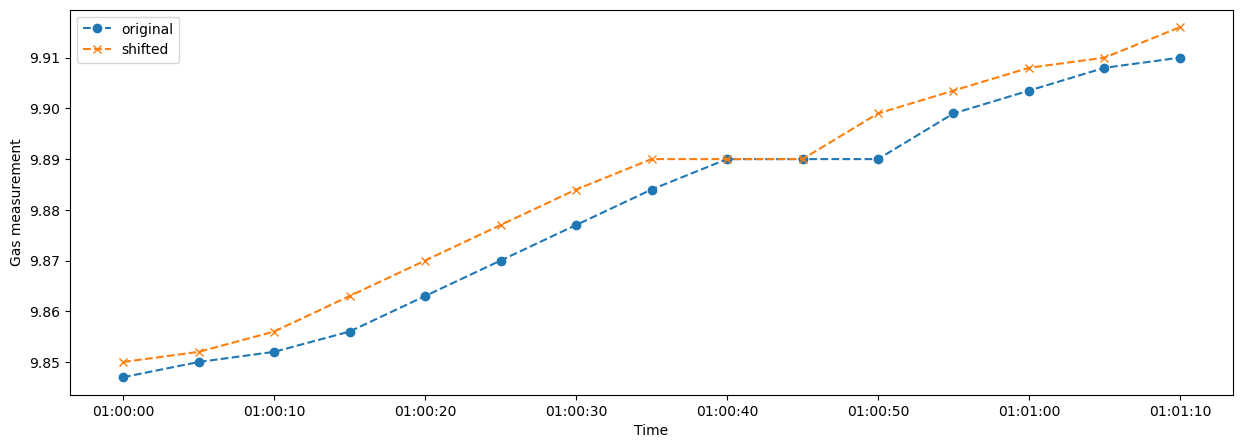

In [ ]:
# Zoom in a small set of observations 
fig,ax = plt.subplots(1,1,figsize = (15,5));
datarange = np.array(range(0,15,1))
ax.plot(steel_converter_data_frequency_enforced.iloc[datarange,-1],'o--',label = 'original');
ax.plot(steel_converter_data_frequency_enforced_shifted.iloc[datarange,-1],'x--',label = 'shifted');
ax.set_ylabel('Gas measurement');
ax.set_xlabel('Time');
# ax.axvline(y = pd.to_datetime('01:00:30'))
ax.legend();

The above figure illustrates that the gas measurements are lagged by 5 seconds, as desired.

Second check: are the final temperature values treated appropriately in the modified (i.e. gas measurement shifted) dataframe?

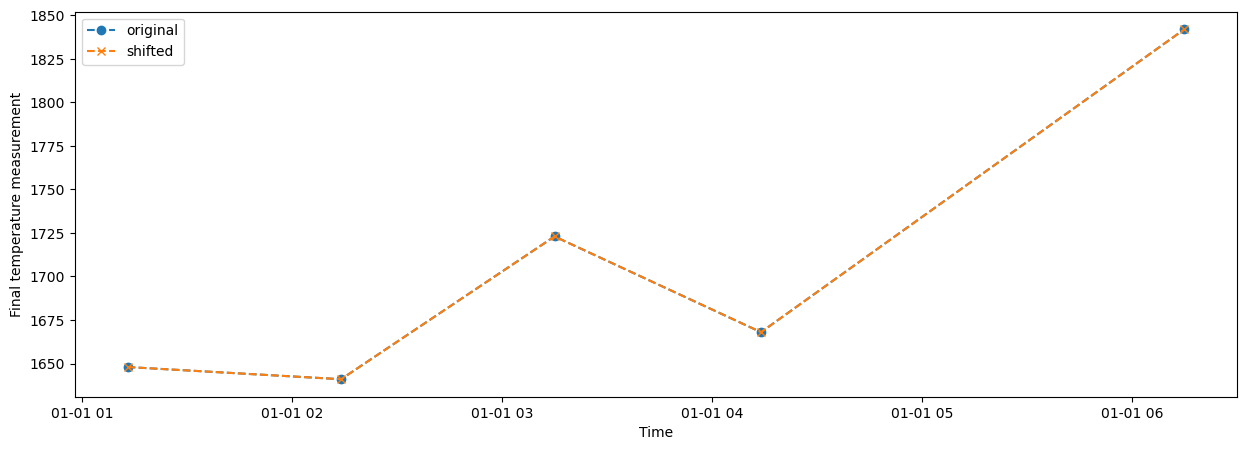

In [ ]:
# Compare temperature values in shifted & original dataset
steel_converter_data_frequency_enforced_temp_only = steel_converter_data_frequency_enforced.dropna(inplace=False)
steel_converter_data_frequency_enforced_shifted_temp_only = steel_converter_data_frequency_enforced_shifted.dropna(inplace=False)

#Plot both the unshifted and the shifted dataset
fig,ax = plt.subplots(1,1,figsize = (15,5));
datarange = np.array(range(0,5,1))
ax.plot(steel_converter_data_frequency_enforced_temp_only.iloc[datarange,1],'o--',label = 'original');
ax.plot(steel_converter_data_frequency_enforced_shifted_temp_only.iloc[datarange,1],'x--',label = 'shifted');
ax.set_ylabel('Final temperature measurement');
ax.set_xlabel('Time');
ax.legend();

Evidently, the final temperatures are still at the correct places.

The checks suggest that the gas measurement shifting has been performed appropriately.

**Task 2 Discussion** 

A set of measurements can be grouped together as a single observation (datapoint) if these measurements occurred together in time, i.e., if they have the same timestamps. Timestamps show how measurements evolved over time. Therefore, timestamps allow coordination of different measurements, as well as structuring of these measurements over time. Therefore, the timestamp is a foundational structural attribute of any process dataset.


If a given measurement has a delay that needs to be compensated for, or if different measurements are measured at different times (rates), then two different sets of timestamps are obtained. This can present a challenge. For instance, consider a situation in which it is desired to compare two measurements, A and B.  Measurement A was recorded at 3:04, 3:08 and 3:12. If we want to model A as a function of B (A = f(B)), we need to know the value of B at 3:04, 3:08 and 3:12. However, measurement B was recorded at slightly different times, namely 3:03, 3:06 and 3:09, but not at the timestamps of interest. Therefore, we cannot use the existing measurement data of B to model A, as we do not know the values of B at the timestamps of interest. We first need to reconcile the timestamps by estimating the value of B at 3:04, 3:08 and 3:12. This illustrates how the timestamp (and the sampling rate) serves as the structural backbone upon which process data rests. Analysis of process data first requires that all data uses the same timestamp (sampling rate).

**Task 3: Modelling temperature as a function of gas measurements**

In Task 1, it was observed that the final temperature measurements are linearly and positively correlated. This motivates the use of a linear model to capture the relationship of temperature as a function of gas measurements. 

Import relevant functions from scikit-learn (sklearn)

In [84]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split

Separate data into training and testing, and train the model.

In [85]:
# Split the final temperature - gas measurement data into test & train sets.
# Note: we assume that subsequent process iterations do not relate to one another. 
gas_train, gas_test, temp_train, temp_test = train_test_split(steel_converter_data_frequency_enforced_shifted_temp_only["gas1"],
                                                               steel_converter_data_frequency_enforced_shifted_temp_only["end_t"], 
                                                               train_size = 0.75, shuffle=False,random_state = 42)

# No standardization was performed prior to modelling. This is not needed for simple linear models. 
# Furthermore, not standardizing means that the measurement units are retained, which is useful in interpreting model parameters.

# Bring data into appropriate form for use with sklearn model fitting function
train_index = gas_train.index
gas_train = gas_train.to_numpy().reshape(-1,1)
temp_train = temp_train.to_numpy().reshape(-1,1)

test_index = gas_test.index
gas_test = gas_test.to_numpy().reshape(-1,1)
temp_test = temp_test.to_numpy().reshape(-1,1)

# Fit model
T_model = LinearRegression().fit(gas_train,temp_train)
# Provide correlations of training data, as well as predictions of test data.
temp_train_model = T_model.predict(gas_train)
temp_test_model = T_model.predict(gas_test)

# Compute model performance metrics
MAE = mean_absolute_error(temp_test, temp_test_model)
MAPE = mean_absolute_percentage_error(temp_test, temp_test_model)*100 #sklearn quirk: mean absolute percentage error needs to be multiplied by 100
R2 = r2_score(temp_test, temp_test_model)

print(f"Mean absolute error (°C): {MAE:.2f}")
print(f"Mean absolute percentage error (%): {MAPE:.2f}")
print(f"Coefficient of determination (-): {R2:.3f}")

Mean absolute error (°C): 1.31
Mean absolute percentage error (%): 0.08
Coefficient of determination (-): 0.999


Given that the temperatures are on the order of 1500°C, an MAE of 1.27 °C is very low. 
This is further confirmed by the MAPE, which is very low. MAPE should always be used in conjunction with other metrics, as it may become large when the absolute magnitude of the observed data is small. 
Moreover, the coefficient of determination indicates that the model explains 99% of the variation observed in the unseen test data, further indicating that the model performs well.

Visualise model performance via a parity plot and time series plot

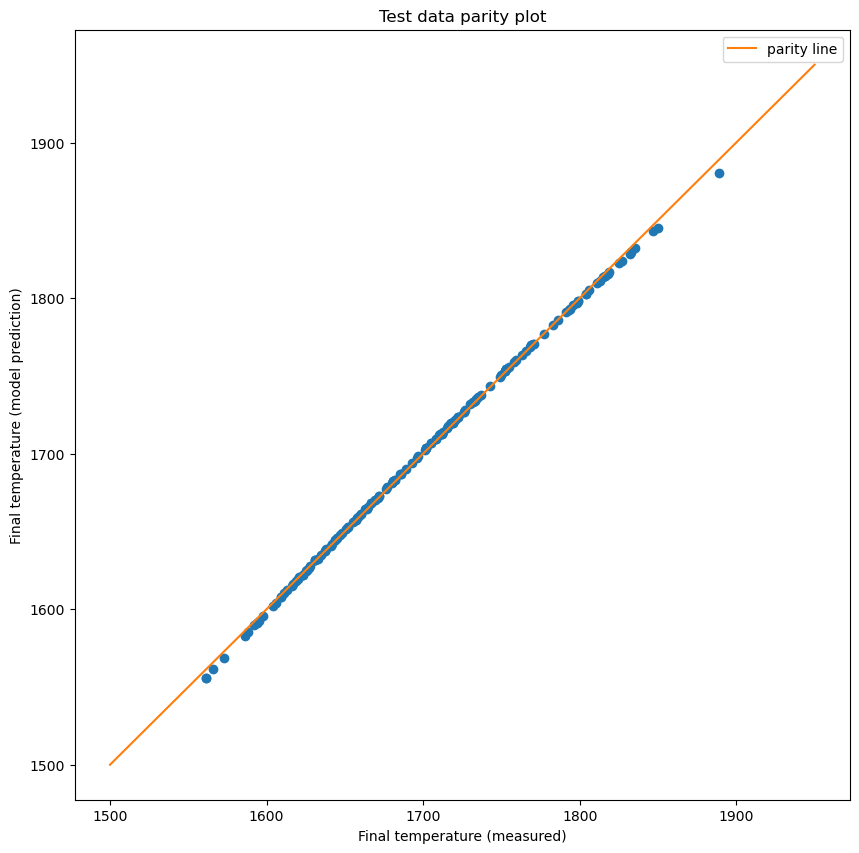

In [86]:
#Provide a parity plot of predicted against measured data
fig,ax = plt.subplots(1,1,figsize = (10,10));

ax.plot(temp_test,temp_test_model,'o');
ax.plot([1500,1950],[1500,1950],label='parity line')
ax.set_xlabel('Final temperature (measured)');
ax.set_ylabel('Final temperature (model prediction)');
ax.legend();
ax.set_title('Test data parity plot');

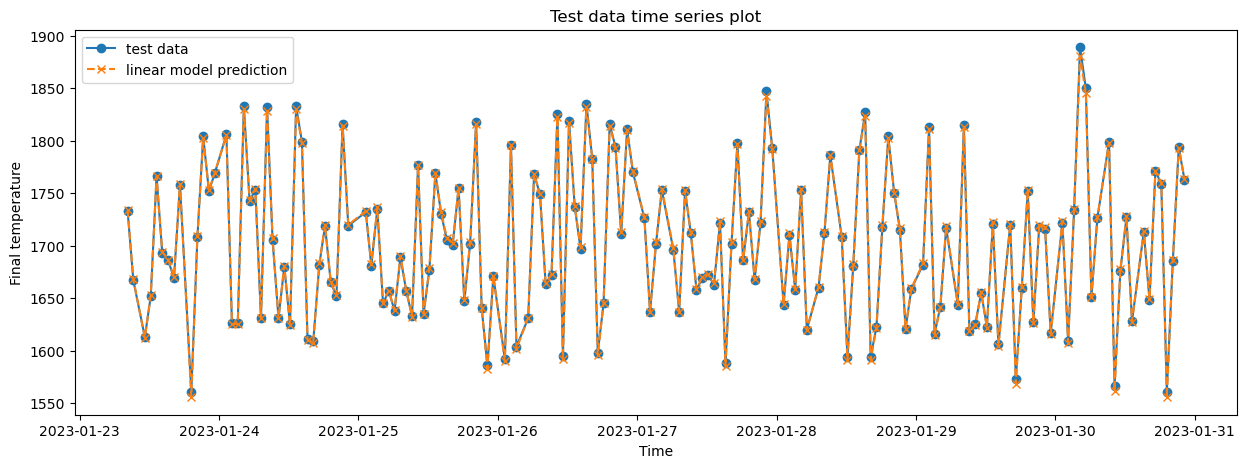

In [87]:
# Plot data and model prediction on time series
fig,ax = plt.subplots(1,1,figsize = (15,5));
ax.plot(test_index,temp_test,'-o',label = 'test data');
ax.plot(test_index,temp_test_model,'--x',label = 'linear model prediction');
ax.set_ylabel('Final temperature');
ax.set_xlabel('Time');
ax.legend();
ax.set_title('Test data time series plot');

The parity plot and time series plot provide further testaments to good model performance, with slight model deterioration at very high & very low temperatures.
The slight deterioration at higher and lower temperatures can be better visualised by plotting the model residual against the temperature.

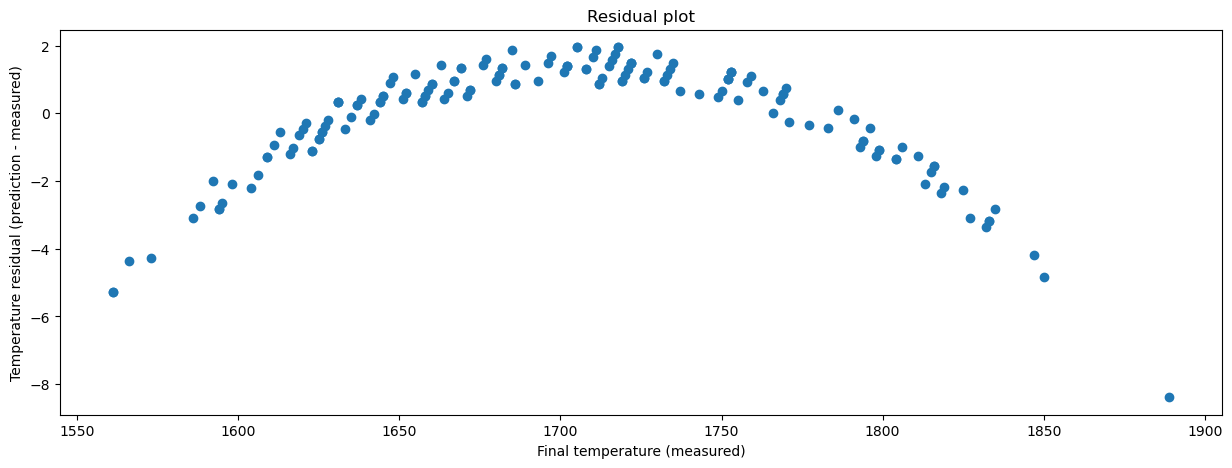

In [88]:
#Plot model residual against temperature
fig,ax = plt.subplots(1,1,figsize = (15,5));

ax.plot(temp_test,temp_test_model-temp_test,'o');
ax.set_ylabel('Temperature residual (prediction - measured)');
ax.set_xlabel('Final temperature (measured)');
ax.set_title('Residual plot');

It's important to stress that the deviations are very small - the temperature values are 3 orders of magnitude larger. Nonetheless, a nonlinear term could be included to account for these minor inaccuracies. Yet this is unlikely to be particularly useful in practice, given the inherently noisy nature of process data. We may end up overfitting more when we move to a more flexible model.

**Task 3 Discussion**

To be useful to a real-time production scenario, we would like to use this model to predict temperatures throughout the process iteration, and not only at the end. This will allow plant personnel to determine the furnace temperature in real-time. 

However, the caveat here is that we only have observations at the very end of the iteration.The linear model is based only on the final temperature measurement. If we want to use the model for the entire process iteration, we need to take temperature readings throughout the entire duration of the process and compare model predictions with these temperature readings. This will determine whether the model is sufficiently accurate not only at the end, but throughout the process iteration. If this validation stage is passed, then the observed linear relationship between gas measurement and temperature holds throughout the process, and not merely for the final temperature, such that the model is suitable for a real-time production scenario. 

Should the model pass this validation, it can be used to estimate furnace temperature of the process during a given iteration, and not only at the end. This can be done by passing the gas measurement to the model in near real-time (with 5 second delay), such that it estimates current furnace temperature.

Accordingly, the model provides plant personnel with the following advantages: 
- Knowledge of the furnace temperature during the process. This helps operators in determining when to stop the process, such that the end temperature is as close as possible to 1680 °C. This more informed approach may lead to fewer shutdowns, and minimise equipment damage. 
- No need to take manual measurements, which are made in a very hazardous process environment. Naturally, measurements will need to be taken periodically to ensure the model remains well calibrated. 


**Task 4: Use of model to minimise restart/overheat losses**

As discussed above, the model allows near real-time estimation of the furnace temperature. Given the 5-second delay in the gas measurement, the model is not quite real-time, but is "near" real-time.

This is useful in two ways: 

 - The model can be used to alarm operators that 1680°C is being approached, and when this temperature has been reached. 

    This allows operators to stop the furnace at precisely the correct temperature, such that costly shutdown penalties are avoided and equipment wear induced by overheat is minimised.


 - The model can also be used to estimate the time remaining until the process reaches 1680°C
 
    This means that operators know how long they roughly need to wait until stopping the iteration. 

The application of the model for a) advising operators to stop the process and b) estimating remainign time is illustrated below.

Scenario: The furnace is currently in operation. Oxygen is being blown, but the furnace is already very hot, and the blow is rapidly reaching its end. The operators are getting ready to stop the oxygen flow, thereby ending the iteration. They are using the model to aid them in determining the time for this.

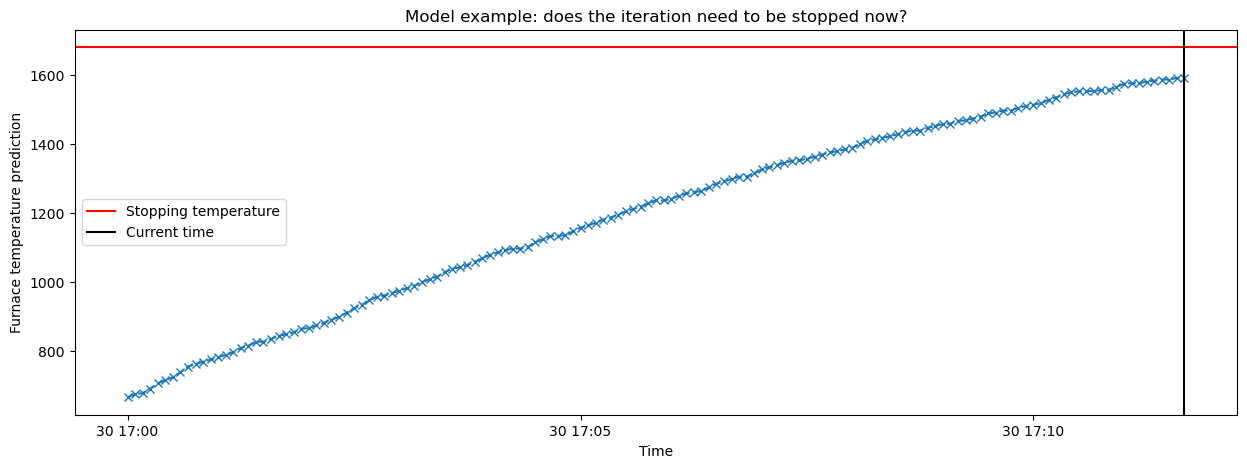

In [89]:
heat = 17206 # chosen heat
#Extract data from chosen heat
heat_of_interest = (steel_converter_data_frequency_enforced_shifted["heatid"] == heat)
data_for_heat = steel_converter_data_frequency_enforced_shifted[heat_of_interest]

#Generate predictions generated to-date for this iteration and plot them.
below_plot_threshold =  T_model.predict(data_for_heat["gas1"].to_numpy().reshape(-1,1)) <= 1600 
data_of_interest = data_for_heat[below_plot_threshold]
model_temp_est = T_model.predict(data_of_interest["gas1"].to_numpy().reshape(-1,1))

fig,ax = plt.subplots(1,1,figsize = (15,5));
ax.plot(data_of_interest.index,model_temp_est,'x--');
ax.set_ylabel('Furnace temperature prediction');
ax.set_xlabel('Time');
ax.axhline(y=1680,color='r',label = 'Stopping temperature');
current_time = data_of_interest.index[-1] #In the simulation, technically 5 seconds ago. The last delay-compensated value.
ax.axvline(x=current_time,color='k',label = 'Current time');
ax.legend();
ax.set_title('Model example: does the iteration need to be stopped now?');

This graph shows the measurement time delay-compensated furnace temperature prediction.This is a useful real-time process monitorig tool with which the operators can view in real-time how the predicted temperature progresses towards the stopping temperature.

A new gas measurement has been recorded at the current time. The model checks this new gas measurement to determine whether the process needs to be stopped or not.

In [ ]:
# Simulation: evaluate newly recorded datapoint
# Assume that this datapoint has just been recorded and processed (delay-shifted)
current_point = steel_converter_data_frequency_enforced_shifted[steel_converter_data_frequency_enforced_shifted.index == current_time]

# Estimate the temperature for this 'current' point
current_temp = T_model.predict(current_point["gas1"].to_numpy().reshape(-1,1))[0][0]

# Raise an alarm if the temperature threshold has been exceeded.
stop_boolean = current_temp >= 1680
if stop_boolean == True:
    print("Stop the process! The stopping temperature has been reached.")
    print(f"Last recorded temperature (°C): {current_temp:.2f} ")
    stopping_time = current_time
else:
    print(f"Last recorded temp (°C): {current_temp:.2f} ")

Last recorded temp (°C): 1592.35 


Because T < 1680°C, the process need not be stopped yet. But it will soon need to be stopped!

Some more time has elapsed. Does the process need to be stopped now?

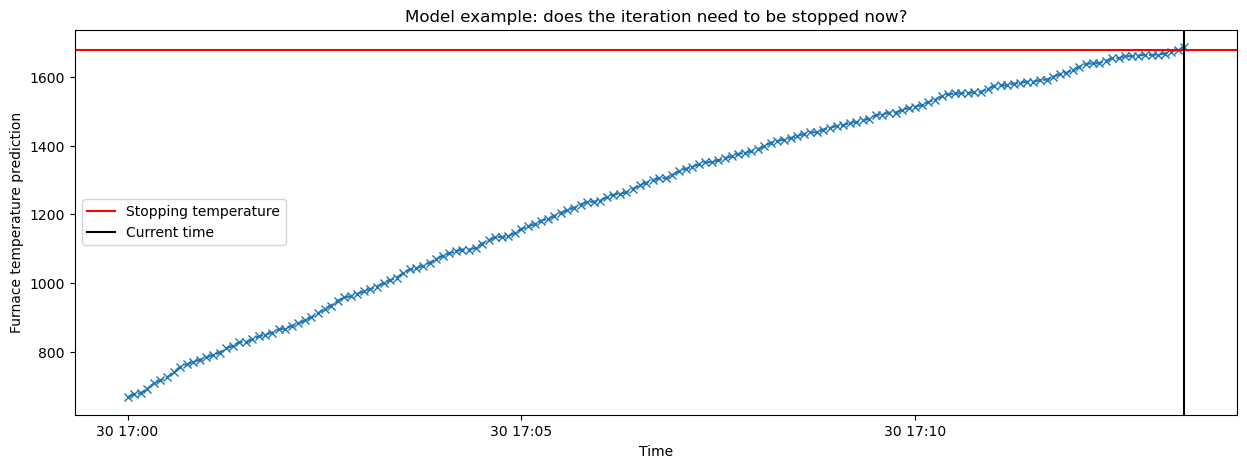

In [95]:
heat = 17206 # chosen heat
#Extract data from chosen heat
heat_of_interest = (steel_converter_data_frequency_enforced_shifted["heatid"] == heat)
data_for_heat = steel_converter_data_frequency_enforced_shifted[heat_of_interest]

#Generate predictions generated to-date for this iteration and plot them.
below_plot_threshold =  T_model.predict(data_for_heat["gas1"].to_numpy().reshape(-1,1)) <= 1687
#note: the threshold is chosen as above 1680. 
data_of_interest = data_for_heat[below_plot_threshold]
model_temp_est = T_model.predict(data_of_interest["gas1"].to_numpy().reshape(-1,1))

fig,ax = plt.subplots(1,1,figsize = (15,5));
ax.plot(data_of_interest.index,model_temp_est,'x--');
ax.set_ylabel('Furnace temperature prediction');
ax.set_xlabel('Time');
ax.axhline(y=1680,color='r',label = 'Stopping temperature');
current_time = data_of_interest.index[-1] #in the simulation, technically 5 seconds ago - the last delay-compensated value
ax.axvline(x=current_time,color='k',label = 'Current time');
ax.legend();
ax.set_title('Model example: does the iteration need to be stopped now?');

In [97]:
# Simulation: evaluate newly recorded datapoint
# Assume that this datapoint has just been recorded and processed (delay-shifted)
current_point = steel_converter_data_frequency_enforced_shifted[steel_converter_data_frequency_enforced_shifted.index == current_time]

# Estimate the temperature for this 'current' point
current_temp = T_model.predict(current_point["gas1"].to_numpy().reshape(-1,1))[0][0]

# Raise an alarm if the temperature threshold has been exceeded.
stop_boolean = current_temp >= 1680
if stop_boolean == True:
    print("Stop the process! The stopping temperature has been reached.")
    print(f"Last recorded temperature (°C): {current_temp:.2f} ")
    stopping_time = current_time
else:
    print(f"Last recorded temp (°C): {current_temp:.2f} ")

Stop the process! The stopping temperature has been reached.
Last recorded temperature (°C): 1686.87 


This value is above the threshold, such that a costly shutdown has been avoided. It is only slightly above 1680°C, such that equipment damage is minimal. 

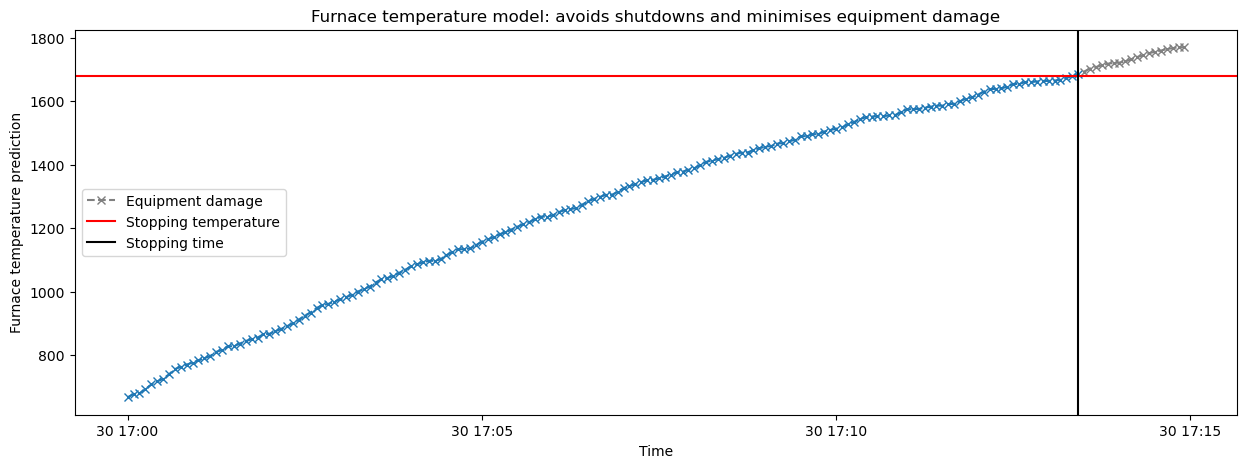

In [100]:
heat = 17206 # chosen heat
#Extract data from chosen heat
heat_of_interest = (steel_converter_data_frequency_enforced_shifted["heatid"] == heat)
data_for_heat = steel_converter_data_frequency_enforced_shifted[heat_of_interest]

#Generate predictions generated to-date for this iteration and plot them.
below_plot_threshold =  T_model.predict(data_for_heat["gas1"].to_numpy().reshape(-1,1)) <= 1687
data_of_interest_below = data_for_heat[below_plot_threshold]
model_temp_est_below = T_model.predict(data_of_interest_below["gas1"].to_numpy().reshape(-1,1))

above_plot_threshold =  T_model.predict(data_for_heat["gas1"].to_numpy().reshape(-1,1)) > 1687
data_of_interest_above = data_for_heat[above_plot_threshold]
model_temp_est_above = T_model.predict(data_of_interest_above["gas1"].to_numpy().reshape(-1,1))

fig,ax = plt.subplots(1,1,figsize = (15,5));
ax.plot(data_of_interest_below.index,model_temp_est_below,'x--');
ax.plot(data_of_interest_above.index,model_temp_est_above,'x--',color = 'gray',label = 'Equipment damage');
ax.set_ylabel('Furnace temperature prediction');
ax.set_xlabel('Time');
ax.axhline(y=1680,color='r',label = 'Stopping temperature');
current_time = stopping_time
ax.axvline(x=current_time,color='k',label = 'Stopping time');
ax.legend();
ax.set_title('Furnace temperature model: avoids shutdowns and minimises equipment damage');

Given that any information available to us is 5 seconds out of date, it may be of interest to set the threshold for stopping the process a little lower. If the current measurement shows that we were at 1677°C 5 seconds ago, we may now be at 1680°C. However, there is a risk inherent to this, as it may be that the threshold has still not been reached in the subsequent 5 seconds. I suspect that the exact value of the stopping threshold can be adjusted slightly depending on subsequent model experience.

**Task 5** 

As illustrated above, the model could take real-time gas measurement data from the SCADA and use this as an input to the model to determine the what the temperature was 5 seconds ago. If this temperature has exceeded the threshold, the operators are notified that they need to end the iteration. 

Furthermore, the delay-compensated recent historical data can also be fed to the model, thereby generating a time series graph of the temperature prediction. The stopping temperature and current time are indicated on this graph, and it is updated as new datapoints are measured. This provides the operators with graphical information about how close the process is to completion. 

Naturally, the model would need to be retrained periodically, especially if there are significant changes further upstream (e.g., changes to ore composition).

In the long run, the usefulness of the model can be measured by reduced variance in the final temperature, as well as a mean final temperature which lies closer to the desired target value.